In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 7/16 I need to figure out how to create a scatter plot subtracting the date of birth from the date of testing and using that as the y-value and total percentile rank as the x-value


In [2]:
evals = pd.read_csv('../partner_eda/partner_project_evals.csv')
evals.head()

C:\Users\plann\AppData\Local\Temp\ipykernel_17072\3454980980.py:1: DtypeWarning: Columns (0,44) have mixed types. Specify dtype option on import or set low_memory=False.
  evals = pd.read_csv('../partner_eda/partner_project_evals.csv')


,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Code 1,Code 2,Code 3,Code 4,Code 5,Code 6,Code 7,Code 8,Code 9,Code 10
0,44879,F,9/27/2022,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16,77-97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,47795,F,12/23/2020,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21,82-96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,54340,M,6/22/2021,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25,81-101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,54344,F,3/7/2022,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,54515,M,11/4/2021,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,5.0,75.0,5,68-88,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
evals = evals.drop_duplicates()
evals.shape

(19500, 220)

In [4]:
eval_dtypes = evals.dtypes.to_frame().reset_index()
eval_dtypes.head()

,index,0
0,Child ID,object
1,Gender,object
2,Date of Birth,object
3,Location - Sub Level 1,object
4,contract number,object


In [5]:
eval_dtypes = eval_dtypes.rename(columns = {'index':'column_name', 0: 'dtype'})
eval_dtypes.head()

,column_name,dtype
0,Child ID,object
1,Gender,object
2,Date of Birth,object
3,Location - Sub Level 1,object
4,contract number,object


In [6]:
evals = evals.replace('<1','0').replace('<0.1','0').replace('>99.9','100')
evals['contract number'] = evals['contract number'].str.replace('contract ','').str.strip()
evals['Program Label'] = evals['Program Label'].str.replace('BDI-3 ','')

evals.head()

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Code 1,Code 2,Code 3,Code 4,Code 5,Code 6,Code 7,Code 8,Code 9,Code 10
0,44879,F,9/27/2022,Southwest,3,Eligibility Evaluation,7.0,85.0,16,77-97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,47795,F,12/23/2020,Greater Nashville,2,Eligibility Evaluation,16.0,88.0,21,82-96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,54340,M,6/22/2021,First Tennessee,1,Eligibility Evaluation,8.0,90.0,25,81-101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,54344,F,3/7/2022,Southeast Tennessee,1,Eligibility Evaluation,13.0,115.0,84,103-123,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,54515,M,11/4/2021,Memphis Delta,3,Eligibility Evaluation,5.0,75.0,5,68-88,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
evals.replace(r'(^\w\w\w\-)', '1/',regex = True)


,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Code 1,Code 2,Code 3,Code 4,Code 5,Code 6,Code 7,Code 8,Code 9,Code 10
0,44879,F,9/27/2022,Southwest,3,Eligibility Evaluation,7.0,85.0,16,77-97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,47795,F,12/23/2020,Greater Nashville,2,Eligibility Evaluation,16.0,88.0,21,82-96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,54340,M,6/22/2021,First Tennessee,1,Eligibility Evaluation,8.0,90.0,25,81-101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,54344,F,3/7/2022,Southeast Tennessee,1,Eligibility Evaluation,13.0,115.0,84,1/123,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,54515,M,11/4/2021,Memphis Delta,3,Eligibility Evaluation,5.0,75.0,5,68-88,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23942,SP03287,F,9/25/2023,Memphis Delta,3,Eligibility Evaluation,13.0,115.0,84,1/123,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23943,SP03288,F,5/18/2021,South Central,2,Eligibility Evaluation,25.0,115.0,84,1/121,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23944,SP03289,F,10/31/2021,South Central,2,Eligibility Evaluation,21.0,103.0,58,96-110,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23945,SP03290,M,3/25/2020,Memphis Delta,3,Annual Evaluation,16.0,88.0,21,82-96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
eval_dtypes.head()

,column_name,dtype
0,Child ID,object
1,Gender,object
2,Date of Birth,object
3,Location - Sub Level 1,object
4,contract number,object


In [9]:
evals = evals.drop(columns = ['Code 1','Code 2','Code 3','Code 4','Code 5','Code 6','Code 7','Code 8','Code 9','Code 10'])

1. In which domains (and sub-domains) are children performing highest and lowest?

In [10]:
domains = evals[['Adaptive Percentile Rank','Social-Emotional Percentile Rank','Communication Percentile Rank','Motor Percentile Rank','Cognitive Percentile Rank']]

In [11]:
domains = domains.rename(columns = {'Adaptive Percentile Rank': 'Adaptive','Social-Emotional Percentile Rank':'Social-Emotional','Communication Percentile Rank':'Communication','Motor Percentile Rank':'Motor','Cognitive Percentile Rank':'Cognitive'})
domains.head()

,Adaptive,Social-Emotional,Communication,Motor,Cognitive
0,16,96,27,21,50
1,21,61,42,55,50
2,25,27,12,73,13
3,84,58,21,27,81
4,5,4,2,4,42


In [12]:
domains = domains[['Adaptive',	'Social-Emotional',	'Communication',	'Motor',	'Cognitive']].astype(float)
domains.head()

,Adaptive,Social-Emotional,Communication,Motor,Cognitive
0,16.0,96.0,27.0,21.0,50.0
1,21.0,61.0,42.0,55.0,50.0
2,25.0,27.0,12.0,73.0,13.0
3,84.0,58.0,21.0,27.0,81.0
4,5.0,4.0,2.0,4.0,42.0


In [13]:
# run Q2 before this cell
domains['Adaptive'] = domains['Adaptive'].mean()
domains['Social-Emotional'] = domains['Social-Emotional'].mean()
domains['Communication'] = domains['Communication'].mean()
domains['Motor'] = domains['Motor'].mean()
domains['Cognitive'] = domains['Cognitive'].mean()

domains = domains.head(1)
domains

,Adaptive,Social-Emotional,Communication,Motor,Cognitive
0,29.911158,40.688282,21.567692,41.665266,31.450459


Text(0.5, 0, 'value')

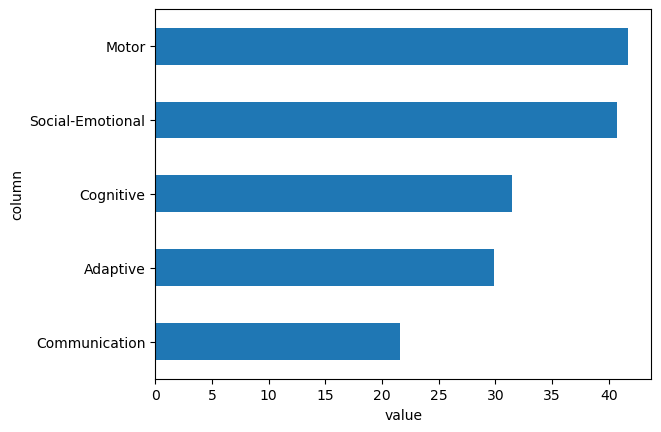

In [14]:
domains.T.sort_values(by = 0, ascending = True).plot(kind = 'barh',legend = False)
plt.ylabel('column')
plt.xlabel('value')


In [15]:
domains.T #.T transposes columns and rows

,0
Adaptive,29.911158
Social-Emotional,40.688282
Communication,21.567692
Motor,41.665266
Cognitive,31.450459


2. What is the pattern of children's scores? Do individual children tend to perform similarly across all domains or are there differences from domain to domain? Are these patterns similar for all children?

In [16]:
domains

,Adaptive,Social-Emotional,Communication,Motor,Cognitive
0,29.911158,40.688282,21.567692,41.665266,31.450459


3. Is there a pattern of significant differences in children's scores in the sub-domains within a domain? For example, a gap between a child's expressive (talking) and receptive (understanding) language scores may indicate that additional evaluation is needed for that child's eligibility. A gap between these sub-domains for all or most children may indicate the BDI-3 tool may lack sensitivity in the language domain.

4. Does the child's age seem to impact their scoring?

In [17]:
evals.head()

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts RS,Cognitive-Perception and Concepts SS,Cognitive-Perception and Concepts PR,Cognitive-Perception and Concepts AE,Cognitive-Perception and Concepts RDI,Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE
0,44879,F,9/27/2022,Southwest,3,Eligibility Evaluation,7.0,85.0,16,77-97,...,9.0,13.0,84,12,98/90,411.0,392 - 431,1,60.0,71
1,47795,F,12/23/2020,Greater Nashville,2,Eligibility Evaluation,16.0,88.0,21,82-96,...,11.0,7.0,16,18,29/90,437.0,421 - 453,– 1.00,40.0,29
2,54340,M,6/22/2021,First Tennessee,1,Eligibility Evaluation,8.0,90.0,25,81-101,...,10.0,7.0,16,15,37/90,426.0,408 - 444,– 1.00,40.0,29
3,54344,F,3/7/2022,Southeast Tennessee,1,Eligibility Evaluation,13.0,115.0,84,103-123,...,9.0,10.0,50,12,92/90,411.0,392 - 431,0,50.0,50
4,54515,M,11/4/2021,Memphis Delta,3,Eligibility Evaluation,5.0,75.0,5,68-88,...,10.0,10.0,50,15,88/90,426.0,408 - 444,0,50.0,50


In [18]:
scoring_age = evals[['Date of Birth','BDI-3 Total Developmental Quotient','Adaptive-Self Care Date of Testing']]
scoring_age.head()

,Date of Birth,BDI-3 Total Developmental Quotient,Adaptive-Self Care Date of Testing
0,9/27/2022,99.0,6/23/2023
1,12/23/2020,99.0,3/21/2023
2,6/22/2021,89.0,4/6/2023
3,3/7/2022,101.0,2/23/2023
4,11/4/2021,71.0,2/24/2023


In [19]:
scoring_age['Date of Birth'] = pd.to_datetime(scoring_age['Date of Birth'])
scoring_age['Adaptive-Self Care Date of Testing'] = pd.to_datetime(scoring_age['Adaptive-Self Care Date of Testing'])
scoring_age = scoring_age.rename(columns = {'Adaptive-Self Care Date of Testing' :'Date of Testing'})

scoring_age.head()

C:\Users\plann\AppData\Local\Temp\ipykernel_17072\2139644323.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scoring_age['Date of Birth'] = pd.to_datetime(scoring_age['Date of Birth'])
C:\Users\plann\AppData\Local\Temp\ipykernel_17072\2139644323.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scoring_age['Adaptive-Self Care Date of Testing'] = pd.to_datetime(scoring_age['Adaptive-Self Care Date of Testing'])


,Date of Birth,BDI-3 Total Developmental Quotient,Date of Testing
0,2022-09-27,99.0,2023-06-23
1,2020-12-23,99.0,2023-03-21
2,2021-06-22,89.0,2023-04-06
3,2022-03-07,101.0,2023-02-23
4,2021-11-04,71.0,2023-02-24


In [20]:
scoring_age['BDI-3 Total Developmental Quotient']=scoring_age['BDI-3 Total Developmental Quotient'].astype(float)
scoring_age.head()

,Date of Birth,BDI-3 Total Developmental Quotient,Date of Testing
0,2022-09-27,99.0,2023-06-23
1,2020-12-23,99.0,2023-03-21
2,2021-06-22,89.0,2023-04-06
3,2022-03-07,101.0,2023-02-23
4,2021-11-04,71.0,2023-02-24


In [21]:
scoring_age.dtypes

Date of Birth                         datetime64[ns]
BDI-3 Total Developmental Quotient           float64
Date of Testing                       datetime64[ns]
dtype: object

In [22]:
# Source - https://stackoverflow.com/a/40924041
# Posted by akuiper, modified by community. See post 'Timeline' for change history
# Retrieved 2026-07-17, License - CC BY-SA 4.0

#12 * (df.today.dt.year - df.date.dt.year) + (df.today.dt.month - df.date.dt.month)




In [23]:
scoring_age['age in months'] = 12 * (scoring_age['Date of Testing'].dt.year - scoring_age['Date of Birth'].dt.year) + (scoring_age['Date of Testing'].dt.month - scoring_age['Date of Birth'].dt.month)
scoring_age.head()

,Date of Birth,BDI-3 Total Developmental Quotient,Date of Testing,age in months
0,2022-09-27,99.0,2023-06-23,9.0
1,2020-12-23,99.0,2023-03-21,27.0
2,2021-06-22,89.0,2023-04-06,22.0
3,2022-03-07,101.0,2023-02-23,11.0
4,2021-11-04,71.0,2023-02-24,15.0


In [24]:
evals.columns

Index(['Child ID', 'Gender', 'Date of Birth', 'Location - Sub Level 1',
       'contract number', 'Program Label', 'Adaptive Sum of Scaled Scores',
       'Adaptive Developmental Quotient', 'Adaptive Percentile Rank',
       'Adaptive 95% Confidence Interval',
       ...
       'Cognitive-Perception and Concepts RS',
       'Cognitive-Perception and Concepts SS',
       'Cognitive-Perception and Concepts PR',
       'Cognitive-Perception and Concepts AE',
       'Cognitive-Perception and Concepts RDI',
       'Cognitive-Perception and Concepts CSS',
       'Cognitive-Perception and Concepts CSS 90%',
       'Cognitive-Perception and Concepts Z-Score',
       'Cognitive-Perception and Concepts T-Score',
       'Cognitive-Perception and Concepts NCE'],
      dtype='object', length=210)

In [25]:
evals_ot = evals.loc[evals['Child ID'].duplicated()].reset_index(drop=True)
evals_ot.head()

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts RS,Cognitive-Perception and Concepts SS,Cognitive-Perception and Concepts PR,Cognitive-Perception and Concepts AE,Cognitive-Perception and Concepts RDI,Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE
0,483662,F,2/29/2020,South Central,2,Annual Evaluation,24.0,112.0,79,104-118,...,14.0,6.0,9,28,Dec-90,471.0,459 - 484,– 1.33,37.0,22
1,485509,F,5/20/2020,Greater Nashville,2,Annual Evaluation,17.0,91.0,27,85-99,...,12.0,4.0,2,22,Feb-90,451.0,429 - 473,– 2.00,30.0,8
2,488572,F,8/3/2020,Upper Cumberland,2,Annual Evaluation,12.0,76.0,5,70-84,...,14.0,7.0,16,28,45/90,471.0,459 - 484,– 1.00,40.0,29
3,489325,F,6/2/2023,Upper Cumberland,2,Annual Evaluation,19.0,145.0,99.9,129-149,...,14.0,19.0,>99,28,>99/90,471.0,459 - 484,3,80.0,>99
4,489576,F,7/8/2020,Greater Nashville,2,Annual Evaluation,10.0,70.0,2,65-79,...,11.0,5.0,5,18,Feb-90,437.0,421 - 453,– 1.67,33.0,15


In [26]:
evals_ot = evals_ot[['Child ID','Communication-Expressive Communication CSS','Date of Birth','Adaptive-Self Care Date of Testing']]
evals_ot.head()

,Child ID,Communication-Expressive Communication CSS,Date of Birth,Adaptive-Self Care Date of Testing
0,483662,474.0,2/29/2020,7/18/2023
1,485509,438.0,5/20/2020,10/26/2023
2,488572,455.0,8/3/2020,6/15/2023
3,489325,466.0,6/2/2023,8/7/2023
4,489576,442.0,7/8/2020,6/14/2023


In [27]:
evals_ot['Date of Birth'] = pd.to_datetime(evals_ot['Date of Birth'])
evals_ot['Adaptive-Self Care Date of Testing'] = pd.to_datetime(evals_ot['Adaptive-Self Care Date of Testing'])
evals_ot = evals_ot.rename(columns = {'Adaptive-Self Care Date of Testing' :'Date of Testing'})

evals_ot.head()

,Child ID,Communication-Expressive Communication CSS,Date of Birth,Date of Testing
0,483662,474.0,2020-02-29,2023-07-18
1,485509,438.0,2020-05-20,2023-10-26
2,488572,455.0,2020-08-03,2023-06-15
3,489325,466.0,2023-06-02,2023-08-07
4,489576,442.0,2020-07-08,2023-06-14


In [28]:
evals_ot['age in months'] = 12 * (evals_ot['Date of Testing'].dt.year - evals_ot['Date of Birth'].dt.year) + (evals_ot['Date of Testing'].dt.month - evals_ot['Date of Birth'].dt.month)
evals_ot.head()

,Child ID,Communication-Expressive Communication CSS,Date of Birth,Date of Testing,age in months
0,483662,474.0,2020-02-29,2023-07-18,41.0
1,485509,438.0,2020-05-20,2023-10-26,41.0
2,488572,455.0,2020-08-03,2023-06-15,34.0
3,489325,466.0,2023-06-02,2023-08-07,2.0
4,489576,442.0,2020-07-08,2023-06-14,35.0


<Axes: title={'center': 'Communication Score'}, xlabel='age in months'>

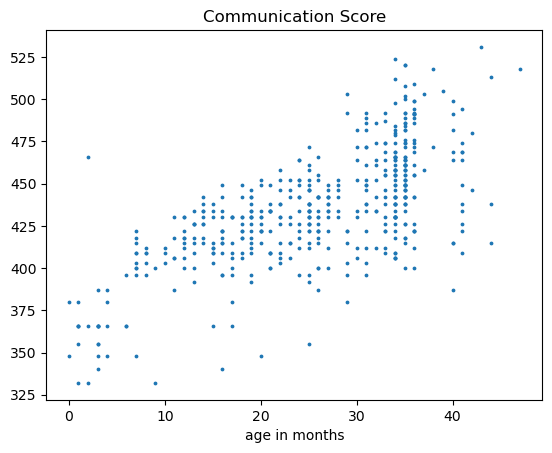

In [29]:
evals_ot.plot.scatter(x = 'age in months', y = 'Communication-Expressive Communication CSS',s = 3,title = 'Communication Score',ylabel = '')

In [30]:
evals_ot[['age in months','Communication-Expressive Communication CSS']].corr().head(1).drop(columns= 'age in months')

,Communication-Expressive Communication CSS
age in months,0.681291


In [31]:
evals.head()

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts RS,Cognitive-Perception and Concepts SS,Cognitive-Perception and Concepts PR,Cognitive-Perception and Concepts AE,Cognitive-Perception and Concepts RDI,Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE
0,44879,F,9/27/2022,Southwest,3,Eligibility Evaluation,7.0,85.0,16,77-97,...,9.0,13.0,84,12,98/90,411.0,392 - 431,1,60.0,71
1,47795,F,12/23/2020,Greater Nashville,2,Eligibility Evaluation,16.0,88.0,21,82-96,...,11.0,7.0,16,18,29/90,437.0,421 - 453,– 1.00,40.0,29
2,54340,M,6/22/2021,First Tennessee,1,Eligibility Evaluation,8.0,90.0,25,81-101,...,10.0,7.0,16,15,37/90,426.0,408 - 444,– 1.00,40.0,29
3,54344,F,3/7/2022,Southeast Tennessee,1,Eligibility Evaluation,13.0,115.0,84,103-123,...,9.0,10.0,50,12,92/90,411.0,392 - 431,0,50.0,50
4,54515,M,11/4/2021,Memphis Delta,3,Eligibility Evaluation,5.0,75.0,5,68-88,...,10.0,10.0,50,15,88/90,426.0,408 - 444,0,50.0,50


In [32]:
css_all = evals.loc[evals['Child ID'].duplicated()].reset_index(drop=True)
css_all.head()

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts RS,Cognitive-Perception and Concepts SS,Cognitive-Perception and Concepts PR,Cognitive-Perception and Concepts AE,Cognitive-Perception and Concepts RDI,Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE
0,483662,F,2/29/2020,South Central,2,Annual Evaluation,24.0,112.0,79,104-118,...,14.0,6.0,9,28,Dec-90,471.0,459 - 484,– 1.33,37.0,22
1,485509,F,5/20/2020,Greater Nashville,2,Annual Evaluation,17.0,91.0,27,85-99,...,12.0,4.0,2,22,Feb-90,451.0,429 - 473,– 2.00,30.0,8
2,488572,F,8/3/2020,Upper Cumberland,2,Annual Evaluation,12.0,76.0,5,70-84,...,14.0,7.0,16,28,45/90,471.0,459 - 484,– 1.00,40.0,29
3,489325,F,6/2/2023,Upper Cumberland,2,Annual Evaluation,19.0,145.0,99.9,129-149,...,14.0,19.0,>99,28,>99/90,471.0,459 - 484,3,80.0,>99
4,489576,F,7/8/2020,Greater Nashville,2,Annual Evaluation,10.0,70.0,2,65-79,...,11.0,5.0,5,18,Feb-90,437.0,421 - 453,– 1.67,33.0,15


In [33]:
# css_all = evals[[
#     'Adaptive-Self Care CSS','Adaptive-Personal Responsibility CSS','Social Emotional-Adult Interaction CSS','Social Emotional-Peer Interaction CSS'
#     ,'Social Emotional-Self Concept / Social Role CSS','Communication-Receptive Communication CSS','Communication-Expressive Communication CSS'
#     ,'Motor-Gross Motor CSS','Motor-Fine Motor CSS','Motor-Perceptual Motor CSS','Cognitive-Attention and Memory CSS','Cognitive-Reasoning / Academic Skills CSS'
#     ,'Cognitive-Perception and Concepts CSS'
#     ,'Date of Birth','Adaptive-Self Care Date of Testing'
# ]]
# css_all.head()

In [34]:
css_all = evals[['Motor-Gross Motor CSS' ,'Date of Birth','Adaptive-Self Care Date of Testing']]
css_all.head()

,Motor-Gross Motor CSS,Date of Birth,Adaptive-Self Care Date of Testing
0,368.0,9/27/2022,6/23/2023
1,467.0,12/23/2020,3/21/2023
2,478.0,6/22/2021,4/6/2023
3,378.0,3/7/2022,2/23/2023
4,381.0,11/4/2021,2/24/2023


In [35]:
evals_ot = evals.loc[evals['Child ID'].duplicated()].reset_index(drop=True)
evals_ot.head()

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts RS,Cognitive-Perception and Concepts SS,Cognitive-Perception and Concepts PR,Cognitive-Perception and Concepts AE,Cognitive-Perception and Concepts RDI,Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE
0,483662,F,2/29/2020,South Central,2,Annual Evaluation,24.0,112.0,79,104-118,...,14.0,6.0,9,28,Dec-90,471.0,459 - 484,– 1.33,37.0,22
1,485509,F,5/20/2020,Greater Nashville,2,Annual Evaluation,17.0,91.0,27,85-99,...,12.0,4.0,2,22,Feb-90,451.0,429 - 473,– 2.00,30.0,8
2,488572,F,8/3/2020,Upper Cumberland,2,Annual Evaluation,12.0,76.0,5,70-84,...,14.0,7.0,16,28,45/90,471.0,459 - 484,– 1.00,40.0,29
3,489325,F,6/2/2023,Upper Cumberland,2,Annual Evaluation,19.0,145.0,99.9,129-149,...,14.0,19.0,>99,28,>99/90,471.0,459 - 484,3,80.0,>99
4,489576,F,7/8/2020,Greater Nashville,2,Annual Evaluation,10.0,70.0,2,65-79,...,11.0,5.0,5,18,Feb-90,437.0,421 - 453,– 1.67,33.0,15


In [36]:
css_all['Avg_scores'] =(css_all['Adaptive-Self Care CSS']+css_all['Adaptive-Personal Responsibility CSS']+css_all['Social Emotional-Adult Interaction CSS']+css_all['Social Emotional-Peer Interaction CSS']
    +css_all['Social Emotional-Self Concept / Social Role CSS']+css_all['Communication-Receptive Communication CSS']+css_all['Communication-Expressive Communication CSS']
    +css_all['Motor-Gross Motor CSS']+css_all['Motor-Fine Motor CSS']+css_all['Motor-Perceptual Motor CSS']+css_all['Cognitive-Attention and Memory CSS']+css_all['Cognitive-Reasoning / Academic Skills CSS']
    +css_all['Cognitive-Perception and Concepts CSS']
)
css_all.head()


KeyError: 'Adaptive-Self Care CSS'

In [ ]:
# css_all = css_all[['Date of Birth','Adaptive-Self Care Date of Testing','Avg_scores']]
# css_all.head()

In [ ]:
css_all = css_all.rename(columns = {'Adaptive-Self Care Date of Testing':'Date of Testing','Avg_scores':'Subdomains Avg Score'})
css_all.head()

In [ ]:
css_all['Date of Birth'] = pd.to_datetime(css_all['Date of Birth'])
css_all['Date of Testing'] = pd.to_datetime(css_all['Date of Testing'])

css_all.head()

In [ ]:
css_all['age in months'] = 12 * (css_all['Date of Testing'].dt.year - css_all['Date of Birth'].dt.year) + (css_all['Date of Testing'].dt.month - css_all['Date of Birth'].dt.month)
css_all.head()

In [ ]:
# css_all['Subdomains Avg Score'] = css_all['Subdomains Avg Score']/13
# css_all.head()

In [ ]:
css_all.dtypes

In [ ]:
css_all.plot.scatter(x = 'age in months', y = 'Motor-Gross Motor CSS',s = 3,title = 'Gross Motor CSS',ylabel = '')

this is a good starting answer but it might be a good idea to get a plot for one subdomain within each domain or get an average of all subdomains.

5. Eligibility is currently based on domains. A child would be considered eligible based on a 40% delay in one area or 25% delay in two areas, as determined by Development Quotient (DQ) scores. A DQ of 70 or less indicates a 40% delay, and a DQ between 71 and 78 indicates a 25% delay. If TEIS added an option for eligibility based on the total score on the BDI-3 total score (DQ score of 70 or less), are there any children who would have qualified that did not qualify based on the current method?

6. Is there any difference in scoring noted based on evaluation type?

In [ ]:
evals.head()

In [ ]:
test_type = evals[['Program Label', 'BDI-3 Total Developmental Quotient']]
test_type.head()

In [ ]:
test_plot = pd.pivot_table(test_type
    ,values ='BDI-3 Total Developmental Quotient'
    ,index = 'Program Label'
    )
test_plot = test_plot.reset_index()
test_plot = test_plot.sort_values(by = 'BDI-3 Total Developmental Quotient')
test_plot

In [ ]:
fig, ax = plt.subplots(figsize = (6,4))

bars = plt.barh(test_plot['Program Label'], test_plot['BDI-3 Total Developmental Quotient'])

plt.title('Avg Scores')

plt.bar_label(bars,padding = -65,color = 'white',fontsize = 18,fmt ='{:,.1f}',fontweight = 'bold' )



In [ ]:
test_plot.plot.scatter(x = 'Program Label', y= 'BDI-3 Total Developmental Quotient')

7. Is there any notable pattern of scoring by region? Note: TEIS contracts with three agencies for evaluations (one per grand region) as follows:  
* East TN, First TN and Southeast
* Greater Nashville, Upper Cumberland, and South Central
* Northwest, Southwest, and Memphis Delta

In [58]:
evals.head()

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts RS,Cognitive-Perception and Concepts SS,Cognitive-Perception and Concepts PR,Cognitive-Perception and Concepts AE,Cognitive-Perception and Concepts RDI,Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE
0,44879,F,9/27/2022,Southwest,3,Eligibility Evaluation,7.0,85.0,16,77-97,...,9.0,13.0,84,12,98/90,411.0,392 - 431,1,60.0,71
1,47795,F,12/23/2020,Greater Nashville,2,Eligibility Evaluation,16.0,88.0,21,82-96,...,11.0,7.0,16,18,29/90,437.0,421 - 453,– 1.00,40.0,29
2,54340,M,6/22/2021,First Tennessee,1,Eligibility Evaluation,8.0,90.0,25,81-101,...,10.0,7.0,16,15,37/90,426.0,408 - 444,– 1.00,40.0,29
3,54344,F,3/7/2022,Southeast Tennessee,1,Eligibility Evaluation,13.0,115.0,84,103-123,...,9.0,10.0,50,12,92/90,411.0,392 - 431,0,50.0,50
4,54515,M,11/4/2021,Memphis Delta,3,Eligibility Evaluation,5.0,75.0,5,68-88,...,10.0,10.0,50,15,88/90,426.0,408 - 444,0,50.0,50


In [59]:
region_scores = evals[['contract number','Location - Sub Level 1','BDI-3 Total Developmental Quotient']]
region_scores.head()

,contract number,Location - Sub Level 1,BDI-3 Total Developmental Quotient
0,3,Southwest,99.0
1,2,Greater Nashville,99.0
2,1,First Tennessee,89.0
3,1,Southeast Tennessee,101.0
4,3,Memphis Delta,71.0


In [60]:
region_scores = region_scores.rename(columns = {'Location - Sub Level 1'	: 'Region','BDI-3 Total Developmental Quotient': 'Avg Developmental Quotient'})
region_scores.head()

,contract number,Region,Avg Developmental Quotient
0,3,Southwest,99.0
1,2,Greater Nashville,99.0
2,1,First Tennessee,89.0
3,1,Southeast Tennessee,101.0
4,3,Memphis Delta,71.0


In [61]:
region_region = region_scores.groupby('Region').mean('Avg Developmental Quotient').reset_index()
region_region = region_region.sort_values(by = 'Avg Developmental Quotient', ascending = False)
region_region

,Region,Avg Developmental Quotient
4,Northwest,91.592670
7,Southwest,91.154545
2,Greater Nashville,89.309628
6,Southeast Tennessee,88.235294
3,Memphis Delta,87.450995
0,East Tennessee,87.307923
8,Upper Cumberland,87.137692
1,First Tennessee,87.072997
5,South Central,83.889367


[Text(-38, 0, '91.6'),
 Text(-38, 0, '91.2'),
 Text(-38, 0, '89.3'),
 Text(-38, 0, '88.2'),
 Text(-38, 0, '87.5'),
 Text(-38, 0, '87.3'),
 Text(-38, 0, '87.1'),
 Text(-38, 0, '87.1'),
 Text(-38, 0, '83.9')]

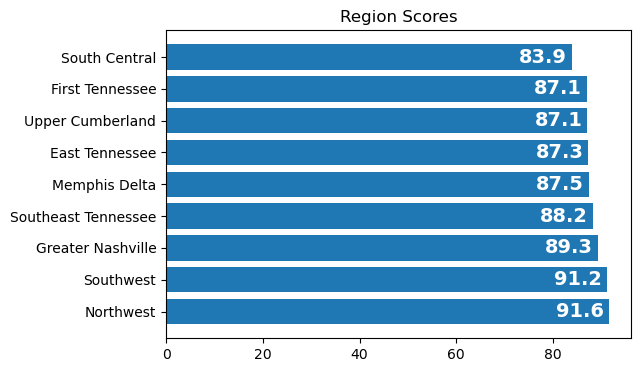

In [62]:
fig, ax = plt.subplots(figsize = (6,4))

bars = plt.barh(region_region['Region'], region_region['Avg Developmental Quotient'])

plt.title('Region Scores')

plt.bar_label(bars,padding = -38,color = 'white',fontsize = 14,fmt ='{:,.1f}',fontweight = 'bold' )

In [63]:
region_scores.head()

,contract number,Region,Avg Developmental Quotient
0,3,Southwest,99.0
1,2,Greater Nashville,99.0
2,1,First Tennessee,89.0
3,1,Southeast Tennessee,101.0
4,3,Memphis Delta,71.0


In [64]:
region_contract = region_scores.groupby('contract number').mean('Avg Developmental Quotient').reset_index()
region_contract = region_contract.sort_values(by = 'contract number', ascending = True)
region_contract = region_contract.rename(columns = {'contract number':'Contract Number'})
region_contract.reset_index(drop=True)

,Contract Number,Avg Developmental Quotient
0,0,85.463415
1,1,87.470142
2,2,87.026645
3,3,89.134619


[Text(0, -38, '85.5'),
 Text(0, -38, '87.5'),
 Text(0, -38, '87.0'),
 Text(0, -38, '89.1')]

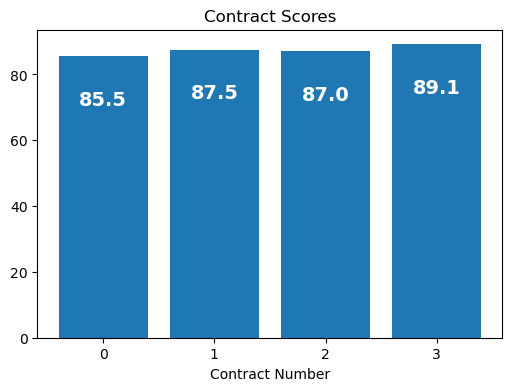

In [67]:
fig, ax = plt.subplots(figsize = (6,4))

bars = plt.bar(region_contract['Contract Number'], region_contract['Avg Developmental Quotient'])

plt.xlabel('Contract Number')

plt.title('Contract Scores')

plt.bar_label(bars,padding = -38,color = 'white',fontsize = 14,fmt ='{:,.1f}',fontweight = 'bold')


8. Is there any notable pattern of scoring by evaluator?

Stretch Goal:
* Investigate the records that are missing ID values. Have they gotten better or worse over time? Are there repeat offenders?
* As noted above, this evaluation may be repeated every 4 months. How often did it occur that a child was assessed multiple times in a time period of less than 120 days. Has this gotten better or worse over time?

In [ ]:
def calc_rect(length, width):
    area = length * width
    print(area)

calc_rect(length = 14, width = 10)